# Teachable Machine Pose model in Python

Runs your exported `my-pose-model` (labels: yes / No / Stop / Help) on `test.jpeg` without a browser.

**How the model works**
1. PoseNet (MobileNetV1, multiplier 0.75, stride 16, 257x257 input) turns the image into heatmaps (17 ch) + offsets (34 ch) on a 17x17 grid.
2. These are flattened into one vector of 17x17x51 = **14739** values.
3. Your Teachable Machine head (`Dense 100 relu -> Dense 4 softmax`) classifies that vector.

Your export only contains step 3. The PoseNet backbone (step 1) is downloaded separately in this notebook, which is why the earlier `KeyError` appeared: the backbone weight names were not what the old code expected.

Put this notebook in the same folder as `model.json`, `weights.bin`, `metadata.json` and `test.jpeg`.

In [1]:
import json, re, urllib.request
from pathlib import Path
import numpy as np
import tensorflow as tf
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

DATA_DIR    = Path(".")                 # folder holding your exported files
IMAGE_PATH  = DATA_DIR / "test.jpeg"
CACHE_DIR   = Path("posenet_cache")
CACHE_DIR.mkdir(exist_ok=True)

# Same settings as metadata.json -> modelSettings.posenet
INPUT_RES     = 257
OUTPUT_STRIDE = 16
POSENET_URL   = "https://storage.googleapis.com/tfjs-models/savedmodel/posenet/mobilenet/float/075/model-stride16.json"
print("TensorFlow", tf.__version__)

TensorFlow 2.21.0


## 1. Generic tfjs weight loader
Reads any tfjs `weightsManifest` (works for both your classifier and the PoseNet graph model).

In [2]:
def load_tfjs_weights(groups, fetch):
    """groups = manifest['weightsManifest']; fetch(path) -> bytes. Returns {name: np.ndarray}."""
    out = {}
    for g in groups:
        blob = b"".join(fetch(p) for p in g["paths"])
        off = 0
        for spec in g["weights"]:
            if "quantization" in spec:
                raise ValueError(f"{spec['name']} is quantized; use the 'float' PoseNet files.")
            dt = np.dtype(spec["dtype"]).newbyteorder("<")
            n = int(np.prod(spec["shape"])) if spec["shape"] else 1
            arr = np.frombuffer(blob, dtype=dt, count=n, offset=off).reshape(spec["shape"])
            out[spec["name"]] = arr.copy()
            off += n * dt.itemsize
        assert off == len(blob), f"Manifest size {off} != file size {len(blob)}"
    return out

def fetch_local(p):
    return (DATA_DIR / p).read_bytes()

def make_fetch_remote(manifest_url):
    base = manifest_url.rsplit("/", 1)[0]
    def _fetch(p):
        f = CACHE_DIR / p
        if not f.exists():
            print("downloading", p)
            urllib.request.urlretrieve(f"{base}/{p}", f)
        return f.read_bytes()
    return _fetch

## 2. Load your Teachable Machine classifier head

In [3]:
meta = json.load(open(DATA_DIR / "metadata.json"))
labels = meta["labels"]
print("labels:", labels, "| posenet settings:", meta["modelSettings"]["posenet"])

model_json = json.load(open(DATA_DIR / "model.json"))
cw = load_tfjs_weights(model_json["weightsManifest"], fetch_local)
W1, b1, W2 = cw["dense_Dense3/kernel"], cw["dense_Dense3/bias"], cw["dense_Dense4/kernel"]
print({k: v.shape for k, v in cw.items()})     # expect (14739,100) (100,) (100,4)

def classify(vec):
    assert vec.shape == (W1.shape[0],), f"feature length {vec.shape} != {W1.shape[0]}"
    h = np.maximum(vec @ W1 + b1, 0.0)          # Dense relu (dropout is off at inference)
    z = h @ W2                                  # Dense 4, no bias
    e = np.exp(z - z.max())
    return e / e.sum()                          # softmax

labels: ['yes', 'No', 'Stop', 'Help'] | posenet settings: {'architecture': 'MobileNetV1', 'outputStride': 16, 'inputResolution': 257, 'multiplier': 0.75}
{'dense_Dense3/kernel': (14739, 100), 'dense_Dense3/bias': (100,), 'dense_Dense4/kernel': (100, 4)}


## 3. Download the PoseNet backbone weights
This is the same file `tmPose` downloads in the browser.

In [4]:
manifest = json.loads(urllib.request.urlopen(POSENET_URL).read())
posenet_weights = load_tfjs_weights(manifest["weightsManifest"], make_fetch_remote(POSENET_URL))
print(len(posenet_weights), "tensors loaded")

# Look at the real names once, so nothing is guessed:
for k in sorted(posenet_weights):
    if re.search(r"Conv2d_(0|1_|13_)|heatmap|offset", k):
        print(f"{k:70s} {posenet_weights[k].shape}")

downloading group1-shard1of2.bin
downloading group1-shard2of2.bin
62 tensors loaded
MobilenetV1/Conv2d_0/weights                                           (3, 3, 3, 24)
MobilenetV1/Conv2d_13_depthwise/depthwise_weights                      (3, 3, 384, 1)
MobilenetV1/Conv2d_13_pointwise/weights                                (1, 1, 384, 384)
MobilenetV1/Conv2d_1_depthwise/depthwise_weights                       (3, 3, 24, 1)
MobilenetV1/Conv2d_1_pointwise/weights                                 (1, 1, 24, 48)
MobilenetV1/MobilenetV1/Conv2d_0/Conv2D_bias                           (24,)
MobilenetV1/MobilenetV1/Conv2d_13_depthwise/depthwise_bias             (384,)
MobilenetV1/MobilenetV1/Conv2d_13_pointwise/Conv2D_bias                (384,)
MobilenetV1/MobilenetV1/Conv2d_1_depthwise/depthwise_bias              (24,)
MobilenetV1/MobilenetV1/Conv2d_1_pointwise/Conv2D_bias                 (48,)
MobilenetV1/heatmap_2/Conv2D_bias                                      (17,)
MobilenetV1/heatmap_2/

## 4. PoseNet MobileNetV1 forward pass

Weights are found **by block name + tensor rank** (4-D = kernel, 1-D = bias), so it works whether the bias is called `biases`, `bias`, `Conv2D_bias` or `depthwise_bias`. If a block is ambiguous, the error lists the candidates.

In [5]:
_tf_cache = {}
def find_tensor(block, ndim):
    key = (block, ndim)
    if key not in _tf_cache:
        pat = re.compile(rf"(^|/){re.escape(block)}/")
        hits = [k for k, v in posenet_weights.items() if pat.search(k) and v.ndim == ndim]
        if len(hits) != 1:
            near = [k for k in posenet_weights if block.lower() in k.lower()]
            raise KeyError(f"Cannot uniquely resolve {ndim}-D tensor for '{block}'. Hits={hits}. Nearby={near}")
        _tf_cache[key] = tf.constant(posenet_weights[hits[0]])
    return _tf_cache[key]

def build_layer_spec(output_stride):
    """Mirrors PoseNet's MobileNet: once the target stride is reached, keep stride 1 and dilate instead."""
    strides = [2, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1]   # Conv2d_0 ... Conv2d_13
    cur, rate, spec = 1, 1, []
    for i, s in enumerate(strides):
        if cur == output_stride:
            ls, lr = 1, rate; rate *= s
        else:
            ls, lr = s, 1;    cur *= s
        spec.append((i, "conv" if i == 0 else "sep", ls, lr))
    return spec

LAYER_SPEC = build_layer_spec(OUTPUT_STRIDE)
print(LAYER_SPEC)

def conv1x1(x, block):
    return tf.nn.bias_add(tf.nn.conv2d(x, find_tensor(block, 4), [1, 1, 1, 1], "SAME"), find_tensor(block, 1))

def run_posenet(x):
    for i, kind, stride, rate in LAYER_SPEC:
        if kind == "conv":
            w, b = find_tensor(f"Conv2d_{i}", 4), find_tensor(f"Conv2d_{i}", 1)
            x = tf.nn.relu6(tf.nn.bias_add(tf.nn.conv2d(x, w, [1, stride, stride, 1], "SAME"), b))
        else:
            dw, dwb = find_tensor(f"Conv2d_{i}_depthwise", 4), find_tensor(f"Conv2d_{i}_depthwise", 1)
            x = tf.nn.depthwise_conv2d(x, dw, [1, stride, stride, 1], "SAME", dilations=[rate, rate])
            x = tf.nn.relu6(tf.nn.bias_add(x, dwb))
            pw, pwb = find_tensor(f"Conv2d_{i}_pointwise", 4), find_tensor(f"Conv2d_{i}_pointwise", 1)
            x = tf.nn.relu6(tf.nn.bias_add(tf.nn.conv2d(x, pw, [1, 1, 1, 1], "SAME"), pwb))
    heatmap_logits = conv1x1(x, "heatmap_2")   # [1,17,17,17]
    offsets        = conv1x1(x, "offset_2")    # [1,17,17,34]
    return heatmap_logits, offsets

[(0, 'conv', 2, 1), (1, 'sep', 1, 1), (2, 'sep', 2, 1), (3, 'sep', 1, 1), (4, 'sep', 2, 1), (5, 'sep', 1, 1), (6, 'sep', 2, 1), (7, 'sep', 1, 1), (8, 'sep', 1, 1), (9, 'sep', 1, 1), (10, 'sep', 1, 1), (11, 'sep', 1, 1), (12, 'sep', 1, 1), (13, 'sep', 1, 2)]


## 5. Preprocess the image and build the 14739-vector

Two details are not stored in your export and cannot be read from the files, so both are switchable:
- `resize_mode`: `"pad"` (letterbox to a square, like PoseNet) or `"stretch"`.
- `use_sigmoid`: whether heatmaps are passed through a sigmoid before flattening.

Step 6 prints results for all four combinations so you can match them against the browser.

image size: (1280, 720)


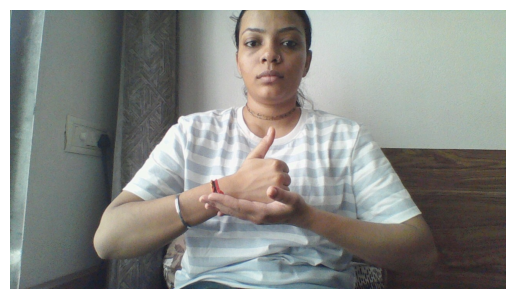

In [6]:
def preprocess(img, resize_mode="pad"):
    img = ImageOps.exif_transpose(img).convert("RGB")
    arr = np.asarray(img, dtype=np.float32)
    if resize_mode == "pad":
        h, w = arr.shape[:2]
        side = max(h, w)
        canvas = np.zeros((side, side, 3), np.float32)
        y0, x0 = (side - h) // 2, (side - w) // 2
        canvas[y0:y0 + h, x0:x0 + w] = arr
        arr = canvas
    x = tf.image.resize(arr[None], [INPUT_RES, INPUT_RES], method="bilinear")
    return x / 127.5 - 1.0                      # MobileNet scaling to [-1, 1]

def feature_vector(img, resize_mode="pad", use_sigmoid=False):
    heat, off = run_posenet(preprocess(img, resize_mode))
    if use_sigmoid:
        heat = tf.sigmoid(heat)
    return tf.concat([heat, off], axis=-1).numpy().reshape(-1)   # 17*17*51 = 14739

img = Image.open(IMAGE_PATH)
print("image size:", img.size)
plt.imshow(ImageOps.exif_transpose(img)); plt.axis("off"); plt.show()

## 6. Predict (all four preprocessing variants)

In [7]:
results = {}
for mode in ("pad", "stretch"):
    for sig in (False, True):
        vec = feature_vector(img, mode, sig)
        results[(mode, sig)] = classify(vec)
        p = results[(mode, sig)]
        print(f"resize={mode:8s} sigmoid={str(sig):5s} -> " +
              "  ".join(f"{l}: {q*100:5.1f}%" for l, q in zip(labels, p)) +
              f"   | top: {labels[int(p.argmax())]}")

resize=pad      sigmoid=False -> yes:   0.0%  No:  93.4%  Stop:   1.8%  Help:   4.7%   | top: No
resize=pad      sigmoid=True  -> yes:   0.0%  No:  94.9%  Stop:   2.0%  Help:   3.1%   | top: No
resize=stretch  sigmoid=False -> yes:   0.8%  No:  92.4%  Stop:   1.6%  Help:   5.2%   | top: No
resize=stretch  sigmoid=True  -> yes:   0.0%  No:  86.5%  Stop:   3.4%  Help:  10.1%   | top: No


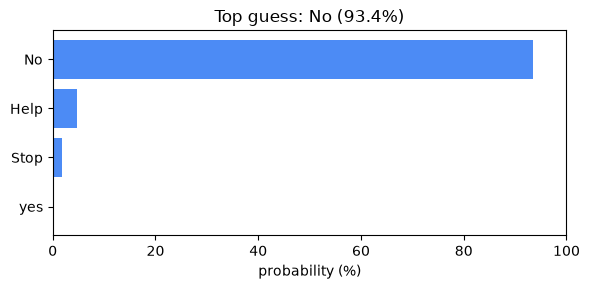

In [8]:
# Pick the variant that matches what the browser (pose_predictor.html) shows for the SAME image.
RESIZE_MODE, USE_SIGMOID = "pad", False

probs = results[(RESIZE_MODE, USE_SIGMOID)]
order = np.argsort(-probs)
plt.figure(figsize=(6, 3))
plt.barh([labels[i] for i in order][::-1], [probs[i] * 100 for i in order][::-1], color="#4c8bf5")
plt.xlabel("probability (%)"); plt.xlim(0, 100)
plt.title(f"Top guess: {labels[order[0]]} ({probs[order[0]]*100:.1f}%)")
plt.tight_layout(); plt.show()

## 7. Check against the browser (recommended)

1. In this folder run `python -m http.server 8000` (opening the HTML by double-click blocks `model.json` loading).
2. Visit `http://localhost:8000/pose_predictor.html` and upload the same `test.jpeg`.
3. Set `RESIZE_MODE` / `USE_SIGMOID` above to the variant whose percentages match the browser.

Small differences (about 1-2 points) are normal because the browser and TensorFlow resize the image slightly differently. If none of the four variants agree, print `posenet_weights` names from step 3 and check that the `find_tensor` calls resolved to the right tensors.

Note: Teachable Machine models are trained on a few samples, so confidence on new images/backgrounds can be low or wrong even when the code is correct.